In [1]:
!pip install transformers accelerate bitsandbytes groq scipy scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 27.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 3.7 MB/s eta 0:00:00ta 0:00:01


In [2]:
import shutil, os, json, time, warnings, zipfile, sys
import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics import roc_auc_score
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
from groq import Groq
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
warnings.filterwarnings('ignore')

DATASET_PATH = "/kaggle/input/datasets/mandaliyatanmay/dna-detectllm-orig"

def _setup_dna_module():
    for root, dirs, files in os.walk(DATASET_PATH):
        if 'dna_detectllm' in dirs:
            src = os.path.join(root, 'dna_detectllm')
            shutil.copytree(src, 'dna_detectllm', dirs_exist_ok=True)
            print(f'Copied folder from: {src}')
            return
        for fname in files:
            if fname == 'dna_detectllm.zip':
                zpath = os.path.join(root, fname)
                with zipfile.ZipFile(zpath) as zf:
                    zf.extractall('.')
                print(f'Extracted zip from: {zpath}')
                return

if not os.path.exists('dna_detectllm'):
    _setup_dna_module()

sys.path.insert(0, os.getcwd())
from dna_detectllm.metrics import sum_perplexity, entropy
os.environ['HF_TOKEN'] = 'YOUR_HF_TOKEN'

DEVICE_1 = 'cuda:0'
DEVICE_2 = 'cuda:1' if torch.cuda.device_count() > 1 else 'cuda:0'
print(f'GPUs: {torch.cuda.device_count()}')

Copied folder from: /kaggle/input/datasets/mandaliyatanmay/dna-detectllm-orig/dna_detectllm
GPUs: 2


In [4]:
from kaggle_secrets import UserSecretsClient
client = Groq(api_key=UserSecretsClient().get_secret("GROQ_API_KEY"))

def llm_generate(prompt, temperature=1.0, max_tokens=400):
    resp = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=max_tokens,
        temperature=temperature)
    return resp.choices[0].message.content.strip()

# Quick test
print(llm_generate("Say hi in one sentence.", temperature=1.0))

Hello, it's nice to meet you and I'm here to help with any questions or topics you'd like to discuss.


In [5]:
!mkdir -p data
BASE = "https://raw.githubusercontent.com/Xiaoweizhu57/DNA-DetectLLM/main/Data"
!wget -q -O data/xsum_human.json "{BASE}/Collected%20data/xsum_human.json"

def load_texts(path):
    with open(path) as f:
        data = json.load(f)
    if isinstance(data, dict):
        for k in ["human_text", "machine_text", "text", "texts"]:
            if k in data: return data[k]
        first = list(data.keys())[0]
        if isinstance(data[first], list): return data[first]
    if isinstance(data, list):
        if isinstance(data[0], str): return data
        if isinstance(data[0], dict) and "text" in data[0]:
            return [d["text"] for d in data]
    raise ValueError(f"Cannot parse {path}")

N = 50
human_texts = load_texts("data/xsum_human.json")[:N]
print(f"Loaded {len(human_texts)} human texts")
print(f"Example: {human_texts[0][:200]}")

Loaded 50 human texts
Example: Two special concerts at the Royal Albert Hall will see pupils perform their own response to 10 pieces of classic music. The Ten Pieces project was announced last year as part of an initiative to inspi


In [6]:
def get_first_sentence(text):
    """Extract first sentence to use as continuation prompt, same approach as paper."""
    for delim in [". ", "! ", "? "]:
        idx = text.find(delim)
        if idx > 40:
            return text[:idx + 1]
    # fallback: first 120 chars up to last space
    chunk = text[:120]
    return chunk[:chunk.rfind(" ")] if " " in chunk else chunk

# Build prompts: first sentence + "Please continue." (paper's exact format)
prompts = [get_first_sentence(t) + " Please continue." for t in human_texts]

print("=== Sample prompts ===")
for p in prompts[:3]:
    print(f"  >> {p}")
    print()

=== Sample prompts ===
  >> Two special concerts at the Royal Albert Hall will see pupils perform their own response to 10 pieces of classic music. Please continue.

  >> Dave Walsh, president of Liverpool Trades Council, said the council should not be afraid of setting an illegal budget. Please continue.

  >> But it has perhaps been more like Pinter than Shakespeare. Please continue.



In [7]:
TEMPERATURES = [0.3, 0.7, 1.0, 1.3, 1.5]

# generated[temp] = list of N texts
generated = {t: [] for t in TEMPERATURES}
failed = {t: [] for t in TEMPERATURES}

total_calls = N * len(TEMPERATURES)
call_count = 0

for i, prompt in enumerate(tqdm(prompts, desc="Generating")):
    for temp in TEMPERATURES:
        try:
            text = llm_generate(prompt, temperature=temp, max_tokens=400)
            generated[temp].append(text)
        except Exception as e:
            print(f"  Failed i={i} temp={temp}: {e}")
            failed[temp].append(i)
            generated[temp].append(None)
            time.sleep(8)
        call_count += 1
        time.sleep(2.5)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{N} done")

print(f"\nTotal calls: {call_count}")
for t in TEMPERATURES:
    n_ok = sum(1 for x in generated[t] if x is not None)
    print(f"  T={t}: {n_ok}/{N} succeeded")

with open("temperature_texts.json", "w") as f:
    json.dump({"human": human_texts, "prompts": prompts,
               "generated": {str(t): generated[t] for t in TEMPERATURES},
               "failed": {str(t): failed[t] for t in TEMPERATURES}}, f, indent=2)
print("Saved temperature_texts.json")

Generating:  20%|██        | 10/50 [03:26<13:44, 20.62s/it]

  10/50 done


Generating:  40%|████      | 20/50 [06:36<09:08, 18.29s/it]

  20/50 done


Generating:  60%|██████    | 30/50 [09:58<07:07, 21.39s/it]

  30/50 done


Generating:  80%|████████  | 40/50 [13:24<03:20, 20.10s/it]

  40/50 done


Generating: 100%|██████████| 50/50 [16:46<00:00, 20.12s/it]

  50/50 done

Total calls: 250
  T=0.3: 50/50 succeeded
  T=0.7: 50/50 succeeded
  T=1.0: 50/50 succeeded
  T=1.3: 50/50 succeeded
  T=1.5: 50/50 succeeded
Saved temperature_texts.json


In [8]:
print("=== Prompt ===")
print(prompts[0])
print()
for t in TEMPERATURES:
    g = generated[t][0]
    print(f"=== T={t} ===")
    print(g[:300] if g else "FAILED")
    print()

=== Prompt ===
Two special concerts at the Royal Albert Hall will see pupils perform their own response to 10 pieces of classic music. Please continue.

=== T=0.3 ===
The two special concerts at the Royal Albert Hall will be a unique opportunity for pupils to showcase their creativity and musical talents. The 10 pieces of classic music that the pupils will be responding to are expected to be a diverse range of works from renowned composers, spanning different era

=== T=0.7 ===
The concerts, which are the culmination of a year-long musical project, will feature over 1,000 pupils from schools across the country. The students, aged between 7 and 18, have been working tirelessly to create their own unique interpretations of 10 iconic classical pieces, including works by Beeth

=== T=1.0 ===
The two special concerts at the Royal Albert Hall will be a unique opportunity for pupils to showcase their creative talents. The 10 pieces of classic music that have inspired the pupils' responses inc

In [9]:
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4"
)

observer = AutoModelForCausalLM.from_pretrained(
    "tiiuae/falcon-7b", quantization_config=quant_config,
    device_map={"": DEVICE_1}, low_cpu_mem_usage=True)
performer = AutoModelForCausalLM.from_pretrained(
    "tiiuae/falcon-7b-instruct", quantization_config=quant_config,
    device_map={"": DEVICE_2}, low_cpu_mem_usage=True)
observer.eval()
performer.eval()

tokenizer = AutoTokenizer.from_pretrained("tiiuae/falcon-7b")
tokenizer.pad_token = tokenizer.eos_token
MAX_LEN = 512

print(f"GPU 0: {torch.cuda.memory_allocated(0)/1e9:.1f} GB")
print(f"GPU 1: {torch.cuda.memory_allocated(1)/1e9:.1f} GB")

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.word_embeddings.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


...

generation_config.json:   0%|          | 0.00/117 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/281 [00:00<?, ?B/s]

GPU 0: 4.9 GB
GPU 1: 4.9 GB


In [10]:
@torch.inference_mode()
def compute_score_full(text):
    """Returns R(s), ppl_std, ppl_max, x_ppl as separate components."""
    enc = tokenizer(text, return_tensors="pt", truncation=True,
                    max_length=MAX_LEN, return_token_type_ids=False)
    obs_logits = observer(**enc.to(DEVICE_1)).logits.float()
    perf_logits = performer(**enc.to(DEVICE_2)).logits.float()

    # --- compute ppl_std and ppl_max separately ---
    shifted_logits = perf_logits[..., :-1, :].to(DEVICE_1)
    attention = enc.attention_mask[..., 1:].to(DEVICE_1)
    labels_std = enc.input_ids[..., 1:].to(DEVICE_1)
    labels_max = torch.argmax(shifted_logits, dim=-1)
    logits_T = shifted_logits.transpose(1, 2)
    ce_std = F.cross_entropy(logits_T, labels_std, reduction='none')
    ce_max = F.cross_entropy(logits_T, labels_max, reduction='none')
    attn_sum = attention.sum(dim=1).clamp(min=1)
    ppl_std = float(((ce_std * attention).sum(dim=1) / attn_sum).cpu())
    ppl_max = float(((ce_max * attention).sum(dim=1) / attn_sum).cpu())

    # --- cross-entropy between observer and performer (entropy) ---
    enc_d1 = enc.to(DEVICE_1)
    x_ppl = float(entropy(obs_logits.to(DEVICE_1), perf_logits.to(DEVICE_1),
                           enc_d1, tokenizer.pad_token_id)[0])

    score = (ppl_std + ppl_max) / (2 * x_ppl)
    return score, ppl_std, ppl_max, x_ppl

def score_list_full(texts, desc):
    results = []
    for t in tqdm(texts, desc=desc):
        if t is None:
            results.append((float('nan'),)*4)
        else:
            try:
                results.append(compute_score_full(t))
            except:
                results.append((float('nan'),)*4)
    return results

# Sanity check
s, ps, pm, xp = compute_score_full("hello world")
print(f"Sanity — R(s)={s:.4f}  ppl_std={ps:.4f}  ppl_max={pm:.4f}  x_ppl={xp:.4f}")

Sanity — R(s)=0.8342  ppl_std=6.2672  ppl_max=1.7516  x_ppl=4.8061


In [11]:
results = {}

human_res = score_list_full(human_texts, "Human")
results["human"] = human_res
print(f"Human done. Mean R(s)={np.nanmean([r[0] for r in human_res]):.4f}")

for temp in TEMPERATURES:
    res = score_list_full(generated[temp], f"T={temp}")
    results[str(temp)] = res
    mean_rs = np.nanmean([r[0] for r in res])
    print(f"T={temp} done. Mean R(s)={mean_rs:.4f}")

with open("temperature_scores.json", "w") as f:
    json.dump({k: v for k, v in results.items()}, f, indent=2)
print("Saved temperature_scores.json")



Human:   0%|          | 0/50 [00:00<?, ?it/s]

Human:   2%|▏         | 1/50 [00:01<01:21,  1.65s/it]

Human:   4%|▍         | 2/50 [00:03<01:11,  1.49s/it]

Human:   6%|▌         | 3/50 [00:04<01:15,  1.61s/it]

Human:   8%|▊         | 4/50 [00:06<01:16,  1.67s/it]

Human:  10%|█         | 5/50 [00:07<01:05,  1.45s/it]

Human:  12%|█▏        | 6/50 [00:09<01:08,  1.55s/it]

Human:  14%|█▍        | 7/50 [00:10<00:59,  1.39s/it]

Human:  16%|█▌        | 8/50 [00:11<00:58,  1.39s/it]

Human:  18%|█▊        | 9/50 [00:13<00:57,  1.41s/it]

Human:  20%|██        | 10/50 [00:15<01:00,  1.52s/it]

Human:  22%|██▏       | 11/50 [00:16<01:00,  1.55s/it]

Human:  24%|██▍       | 12/50 [00:18<00:59,  1.57s/it]

Human:  26%|██▌       | 13/50 [00:20<01:00,  1.64s/it]

Human:  28%|██▊       | 14/50 [00:21<00:56,  1.57s/it]

Human:  30%|███       | 15/50 [00:23<00:57,  1.64s/it]

Human:  32%|███▏      | 16/50 [00:25<00:57,  1.69s/it]

Human:  34%|███▍      | 17/50 [00:26<00:49,  1.50s/it]

Human:  

Human done. Mean R(s)=0.6881




T=0.3:   0%|          | 0/50 [00:00<?, ?it/s]

T=0.3:   2%|▏         | 1/50 [00:01<01:15,  1.53s/it]

T=0.3:   4%|▍         | 2/50 [00:03<01:13,  1.53s/it]

T=0.3:   6%|▌         | 3/50 [00:04<01:04,  1.38s/it]

T=0.3:   8%|▊         | 4/50 [00:05<01:07,  1.48s/it]

T=0.3:  10%|█         | 5/50 [00:07<01:09,  1.53s/it]

T=0.3:  12%|█▏        | 6/50 [00:09<01:08,  1.56s/it]

T=0.3:  14%|█▍        | 7/50 [00:10<01:07,  1.58s/it]

T=0.3:  16%|█▌        | 8/50 [00:12<01:06,  1.57s/it]

T=0.3:  18%|█▊        | 9/50 [00:14<01:07,  1.65s/it]

T=0.3:  20%|██        | 10/50 [00:15<01:07,  1.70s/it]

T=0.3:  22%|██▏       | 11/50 [00:17<01:00,  1.56s/it]

T=0.3:  24%|██▍       | 12/50 [00:18<00:59,  1.57s/it]

T=0.3:  26%|██▌       | 13/50 [00:20<01:00,  1.65s/it]

T=0.3:  28%|██▊       | 14/50 [00:22<00:58,  1.62s/it]

T=0.3:  30%|███       | 15/50 [00:23<00:51,  1.48s/it]

T=0.3:  32%|███▏      | 16/50 [00:24<00:45,  1.34s/it]

T=0.3:  34%|███▍      | 17/50 [00:26<00:49,  1.50s/it]

T=0.3:  

T=0.3 done. Mean R(s)=0.5181




T=0.7:   0%|          | 0/50 [00:00<?, ?it/s]

T=0.7:   2%|▏         | 1/50 [00:01<01:27,  1.79s/it]

T=0.7:   4%|▍         | 2/50 [00:03<01:22,  1.73s/it]

T=0.7:   6%|▌         | 3/50 [00:04<01:10,  1.51s/it]

T=0.7:   8%|▊         | 4/50 [00:06<01:15,  1.64s/it]

T=0.7:  10%|█         | 5/50 [00:08<01:14,  1.66s/it]

T=0.7:  12%|█▏        | 6/50 [00:09<01:13,  1.66s/it]

T=0.7:  14%|█▍        | 7/50 [00:11<01:10,  1.64s/it]

T=0.7:  16%|█▌        | 8/50 [00:13<01:09,  1.65s/it]

T=0.7:  18%|█▊        | 9/50 [00:14<01:08,  1.67s/it]

T=0.7:  20%|██        | 10/50 [00:16<01:06,  1.66s/it]

T=0.7:  22%|██▏       | 11/50 [00:17<01:00,  1.55s/it]

T=0.7:  24%|██▍       | 12/50 [00:19<01:00,  1.60s/it]

T=0.7:  26%|██▌       | 13/50 [00:21<01:01,  1.68s/it]

T=0.7:  28%|██▊       | 14/50 [00:22<00:56,  1.57s/it]

T=0.7:  30%|███       | 15/50 [00:24<00:56,  1.61s/it]

T=0.7:  32%|███▏      | 16/50 [00:25<00:50,  1.49s/it]

T=0.7:  34%|███▍      | 17/50 [00:27<00:50,  1.53s/it]

T=0.7:  

...

T=1.0 done. Mean R(s)=0.5171




T=1.3:   0%|          | 0/50 [00:00<?, ?it/s]

T=1.3:   2%|▏         | 1/50 [00:01<01:32,  1.88s/it]

T=1.3:   4%|▍         | 2/50 [00:03<01:27,  1.82s/it]

T=1.3:   6%|▌         | 3/50 [00:05<01:22,  1.75s/it]

T=1.3:   8%|▊         | 4/50 [00:07<01:23,  1.80s/it]

T=1.3:  10%|█         | 5/50 [00:08<01:19,  1.76s/it]

T=1.3:  12%|█▏        | 6/50 [00:10<01:16,  1.73s/it]

T=1.3:  14%|█▍        | 7/50 [00:12<01:12,  1.70s/it]

T=1.3:  16%|█▌        | 8/50 [00:13<01:10,  1.68s/it]

T=1.3:  18%|█▊        | 9/50 [00:15<01:09,  1.68s/it]

T=1.3:  20%|██        | 10/50 [00:16<01:02,  1.57s/it]

T=1.3:  22%|██▏       | 11/50 [00:18<00:58,  1.50s/it]

T=1.3:  24%|██▍       | 12/50 [00:19<00:58,  1.54s/it]

T=1.3:  26%|██▌       | 13/50 [00:21<00:57,  1.56s/it]

T=1.3:  28%|██▊       | 14/50 [00:22<00:52,  1.46s/it]

T=1.3:  30%|███       | 15/50 [00:24<00:52,  1.51s/it]

T=1.3:  32%|███▏      | 16/50 [00:25<00:52,  1.54s/it]

T=1.3:  34%|███▍      | 17/50 [00:27<00:49,  1.49s/it]

T=1.3:  

T=1.3 done. Mean R(s)=0.5227




T=1.5:   0%|          | 0/50 [00:00<?, ?it/s]

T=1.5:   2%|▏         | 1/50 [00:01<01:27,  1.80s/it]

T=1.5:   4%|▍         | 2/50 [00:03<01:21,  1.69s/it]

T=1.5:   6%|▌         | 3/50 [00:05<01:18,  1.66s/it]

T=1.5:   8%|▊         | 4/50 [00:06<01:17,  1.69s/it]

T=1.5:  10%|█         | 5/50 [00:08<01:15,  1.68s/it]

T=1.5:  12%|█▏        | 6/50 [00:10<01:16,  1.75s/it]

T=1.5:  14%|█▍        | 7/50 [00:11<01:13,  1.70s/it]

T=1.5:  16%|█▌        | 8/50 [00:13<01:10,  1.68s/it]

T=1.5:  18%|█▊        | 9/50 [00:15<01:11,  1.74s/it]

T=1.5:  20%|██        | 10/50 [00:17<01:08,  1.71s/it]

T=1.5:  22%|██▏       | 11/50 [00:18<01:06,  1.72s/it]

T=1.5:  24%|██▍       | 12/50 [00:20<01:06,  1.75s/it]

T=1.5:  26%|██▌       | 13/50 [00:22<01:04,  1.73s/it]

T=1.5:  28%|██▊       | 14/50 [00:23<00:57,  1.59s/it]

T=1.5:  30%|███       | 15/50 [00:24<00:49,  1.43s/it]

T=1.5:  32%|███▏      | 16/50 [00:25<00:44,  1.30s/it]

T=1.5:  34%|███▍      | 17/50 [00:27<00:46,  1.40s/it]

T=1.5:  

T=1.5 done. Mean R(s)=0.5413
Saved temperature_scores.json


In [12]:
def to_arrays(res_list):
    rs    = np.array([r[0] for r in res_list])
    ps    = np.array([r[1] for r in res_list])
    pm    = np.array([r[2] for r in res_list])
    xp    = np.array([r[3] for r in res_list])
    return rs, ps, pm, xp

human_rs, human_ps, human_pm, human_xp = to_arrays(results["human"])

ai_data = {}
for t in TEMPERATURES:
    rs, ps, pm, xp = to_arrays(results[str(t)])
    ai_data[t] = {"rs": rs, "ppl_std": ps, "ppl_max": pm, "x_ppl": xp}

# Summary table
print(f"{'Group':<12} {'R(s) mean':>10} {'R(s) std':>10} {'ppl_std':>10} {'ppl_max':>10} {'x_ppl':>10}")
print("-" * 62)
h = human_rs[~np.isnan(human_rs)]
print(f"{'Human':<12} {np.mean(h):>10.4f} {np.std(h):>10.4f} {np.nanmean(human_ps):>10.4f} {np.nanmean(human_pm):>10.4f} {np.nanmean(human_xp):>10.4f}")
for t in TEMPERATURES:
    v = ai_data[t]["rs"]
    v_ok = v[~np.isnan(v)]
    print(f"{'T='+str(t):<12} {np.mean(v_ok):>10.4f} {np.std(v_ok):>10.4f} {np.nanmean(ai_data[t]["ppl_std"]):>10.4f} {np.nanmean(ai_data[t]["ppl_max"]):>10.4f} {np.nanmean(ai_data[t]["x_ppl"]):>10.4f}")

Group         R(s) mean   R(s) std    ppl_std    ppl_max      x_ppl
--------------------------------------------------------------
Human            0.6881     0.0178     2.4852     1.0423     2.5626
T=0.3            0.5181     0.0531     1.6639     0.8211     2.3865
T=0.7            0.5199     0.0487     1.6801     0.8418     2.4053
T=1.0            0.5171     0.0504     1.7073     0.8355     2.4427
T=1.3            0.5227     0.0542     1.7800     0.8439     2.4934
T=1.5            0.5413     0.0559     1.9059     0.8777     2.5504


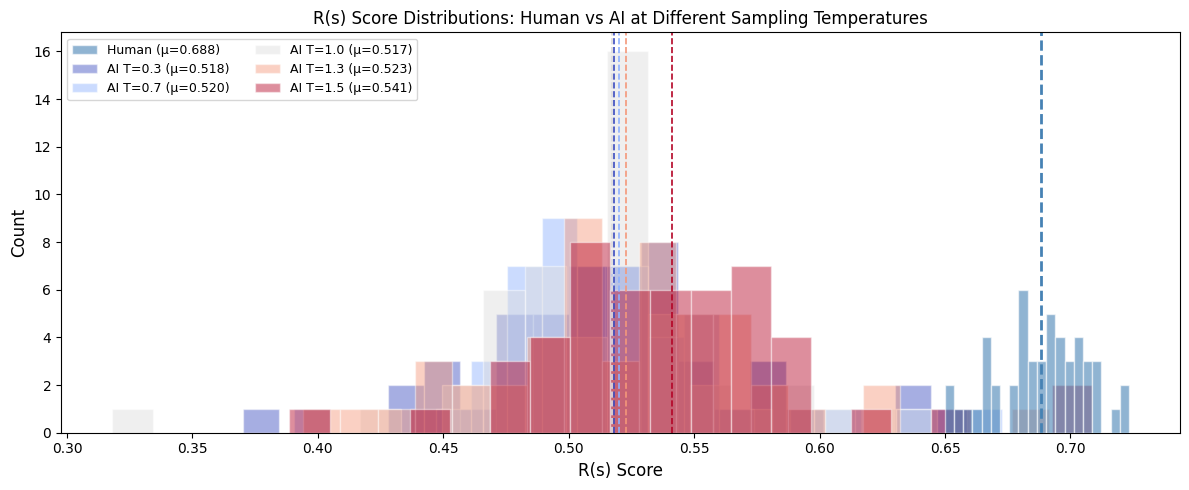

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = cm.coolwarm(np.linspace(0.0, 1.0, len(TEMPERATURES)))
ax.hist(human_rs[~np.isnan(human_rs)], bins=20, alpha=0.6,
        color='steelblue', edgecolor='white', label=f'Human (μ={np.nanmean(human_rs):.3f})', zorder=5)

for i, t in enumerate(TEMPERATURES):
    v = ai_data[t]["rs"]
    v = v[~np.isnan(v)]
    ax.hist(v, bins=20, alpha=0.45, color=colors[i], edgecolor='white',
            label=f'AI T={t} (μ={np.mean(v):.3f})')

ax.axvline(np.nanmean(human_rs), color='steelblue', ls='--', lw=2)
for i, t in enumerate(TEMPERATURES):
    v = ai_data[t]["rs"]
    ax.axvline(np.nanmean(v), color=colors[i], ls='--', lw=1.2)

ax.set_xlabel('R(s) Score', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('R(s) Score Distributions: Human vs AI at Different Sampling Temperatures', fontsize=12)
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig('temp_distributions.png', dpi=150)
plt.show()

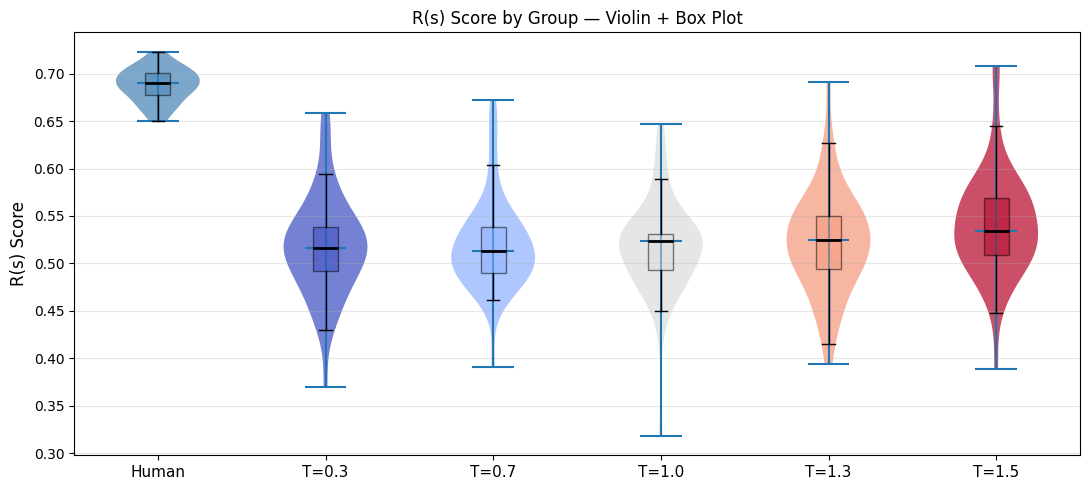

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))

all_groups = [human_rs[~np.isnan(human_rs)]] + [ai_data[t]["rs"][~np.isnan(ai_data[t]["rs"])] for t in TEMPERATURES]
labels = ["Human"] + [f"T={t}" for t in TEMPERATURES]
box_colors = ['steelblue'] + list(cm.coolwarm(np.linspace(0.0, 1.0, len(TEMPERATURES))))

parts = ax.violinplot(all_groups, positions=range(len(all_groups)), showmedians=True, showmeans=False)
for i, (pc, col) in enumerate(zip(parts['bodies'], box_colors)):
    pc.set_facecolor(col)
    pc.set_alpha(0.7)

bp = ax.boxplot(all_groups, positions=range(len(all_groups)), widths=0.15,
                patch_artist=True, showfliers=False,
                medianprops=dict(color='black', lw=2))
for patch, col in zip(bp['boxes'], box_colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.5)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('R(s) Score', fontsize=12)
ax.set_title('R(s) Score by Group — Violin + Box Plot', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('temp_violin.png', dpi=150)
plt.show()

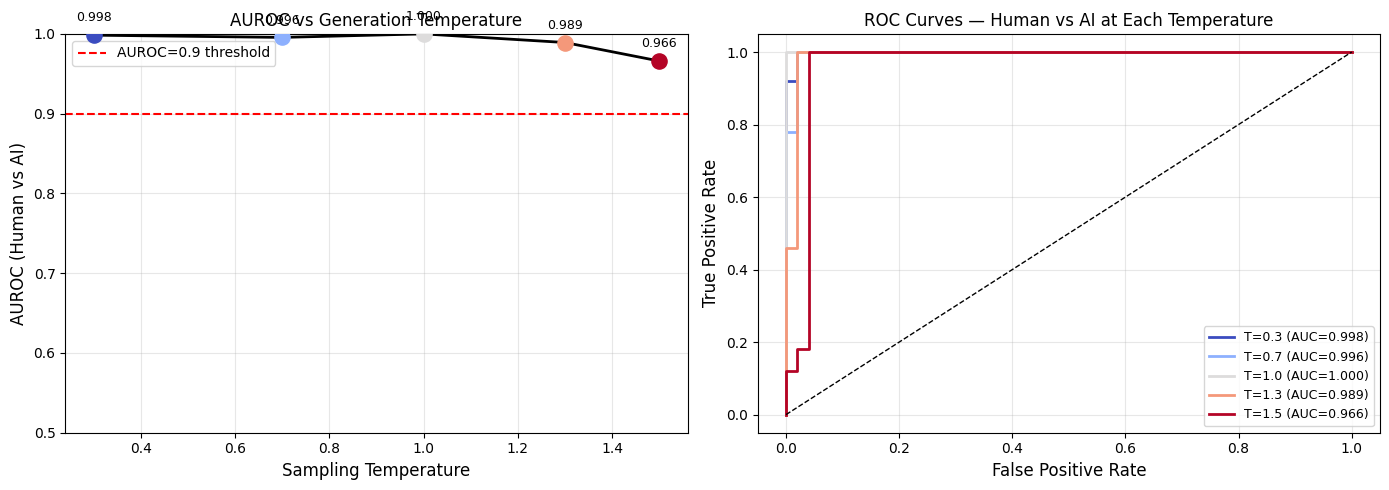

AUROC values: {0.3: np.float64(0.9984), 0.7: np.float64(0.9956), 1.0: np.float64(1.0), 1.3: np.float64(0.9892), 1.5: np.float64(0.966)}


In [15]:
from sklearn.metrics import roc_curve, auc as sk_auc

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: AUROC vs Temperature
aurocs = []
for t in TEMPERATURES:
    v = ai_data[t]["rs"]
    mask = ~np.isnan(human_rs) & ~np.isnan(v)
    y_true = np.concatenate([np.ones(mask.sum()), np.zeros(mask.sum())])
    y_score = np.concatenate([human_rs[mask], v[mask]])
    aurocs.append(roc_auc_score(y_true, y_score))

colors_line = cm.coolwarm(np.linspace(0.0, 1.0, len(TEMPERATURES)))
axes[0].plot(TEMPERATURES, aurocs, 'o-', color='black', lw=2, ms=8, zorder=5)
for i, (t, a) in enumerate(zip(TEMPERATURES, aurocs)):
    axes[0].scatter(t, a, color=colors_line[i], s=120, zorder=6)
    axes[0].annotate(f'{a:.3f}', (t, a), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)

axes[0].axhline(0.9, color='red', ls='--', lw=1.5, label='AUROC=0.9 threshold')
axes[0].set_xlabel('Sampling Temperature', fontsize=12)
axes[0].set_ylabel('AUROC (Human vs AI)', fontsize=12)
axes[0].set_title('AUROC vs Generation Temperature', fontsize=12)
axes[0].set_ylim(0.5, 1.0)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Right: ROC fan plot
for i, t in enumerate(TEMPERATURES):
    v = ai_data[t]["rs"]
    mask = ~np.isnan(human_rs) & ~np.isnan(v)
    y_true = np.concatenate([np.ones(mask.sum()), np.zeros(mask.sum())])
    y_score = np.concatenate([human_rs[mask], v[mask]])
    fpr, tpr, _ = roc_curve(y_true, y_score)
    axes[1].plot(fpr, tpr, color=colors_line[i], lw=2, label=f'T={t} (AUC={aurocs[i]:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curves — Human vs AI at Each Temperature', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('temp_auroc_roc.png', dpi=150)
plt.show()
print(f"AUROC values: {dict(zip(TEMPERATURES, [round(a,4) for a in aurocs]))}")

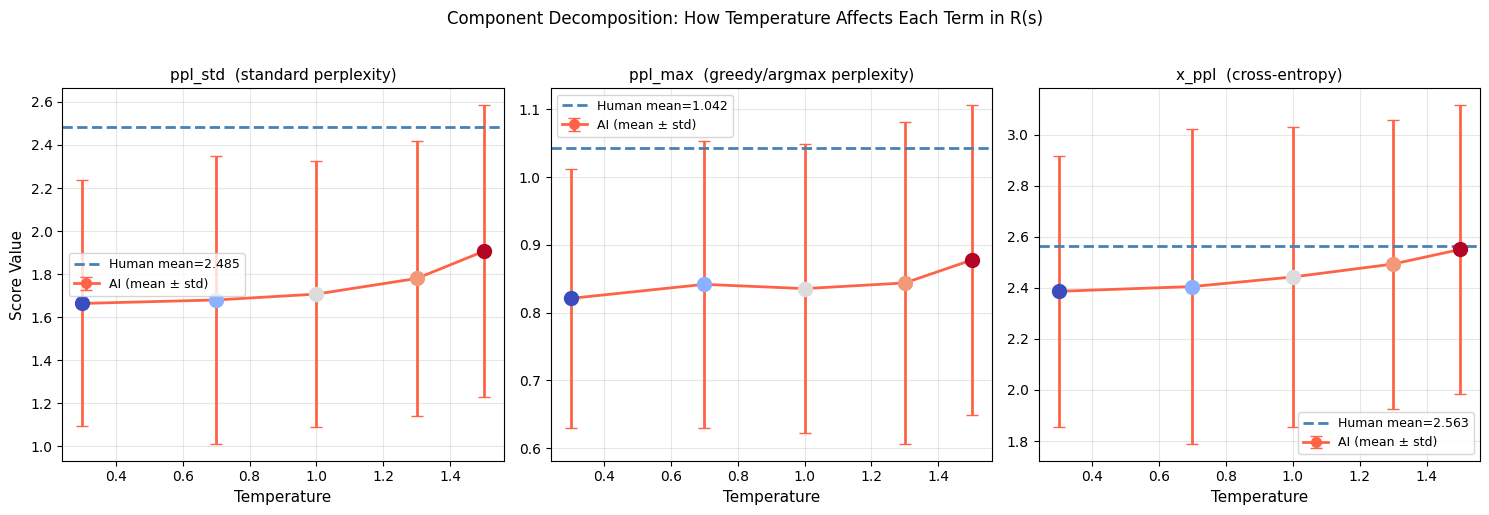

ppl_max is the greedy decoding term — watch how it changes with temperature vs ppl_std


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

component_keys = ["ppl_std", "ppl_max", "x_ppl"]
component_labels = ["ppl_std  (standard perplexity)", "ppl_max  (greedy/argmax perplexity)", "x_ppl  (cross-entropy)"]
human_vals = [np.nanmean(human_ps), np.nanmean(human_pm), np.nanmean(human_xp)]

colors_comp = cm.coolwarm(np.linspace(0.0, 1.0, len(TEMPERATURES)))

for ax, key, label, h_val in zip(axes, component_keys, component_labels, human_vals):
    ai_means = [np.nanmean(ai_data[t][key]) for t in TEMPERATURES]
    ai_stds  = [np.nanstd(ai_data[t][key])  for t in TEMPERATURES]

    ax.errorbar(TEMPERATURES, ai_means, yerr=ai_stds, fmt='o-', color='tomato',
                lw=2, ms=7, capsize=4, label='AI (mean ± std)')
    ax.axhline(h_val, color='steelblue', ls='--', lw=2, label=f'Human mean={h_val:.3f}')

    for i, (t, m) in enumerate(zip(TEMPERATURES, ai_means)):
        ax.scatter(t, m, color=colors_comp[i], s=100, zorder=5)

    ax.set_xlabel('Temperature', fontsize=11)
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Score Value', fontsize=11)
plt.suptitle('Component Decomposition: How Temperature Affects Each Term in R(s)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('temp_components.png', dpi=150, bbox_inches='tight')
plt.show()
print("ppl_max is the greedy decoding term — watch how it changes with temperature vs ppl_std")

Computing greedy match fractions (subset of 20 samples for speed)...
  T=0.3: mean greedy match = 0.600
  T=0.7: mean greedy match = 0.601
  T=1.0: mean greedy match = 0.588
  T=1.3: mean greedy match = 0.586
  T=1.5: mean greedy match = 0.563
  Human: mean greedy match = 0.481


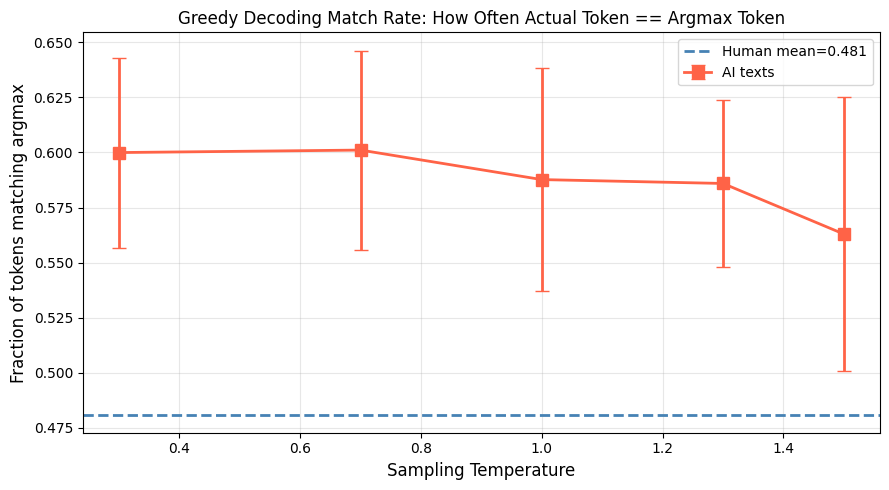

At T=0.3, actual tokens closely follow greedy. At T=1.5, they diverge — the assumption breaks.


In [17]:
@torch.inference_mode()
def greedy_match_fraction(text):
    """What fraction of actual tokens == argmax(logits) at each position?"""
    enc = tokenizer(text, return_tensors="pt", truncation=True,
                    max_length=MAX_LEN, return_token_type_ids=False)
    logits = performer(**enc.to(DEVICE_2)).logits.float()
    shifted_logits = logits[..., :-1, :]
    actual_tokens = enc.input_ids[..., 1:].to(DEVICE_2)
    argmax_tokens  = torch.argmax(shifted_logits, dim=-1)
    attn = enc.attention_mask[..., 1:].to(DEVICE_2)
    matches = ((actual_tokens == argmax_tokens) * attn).sum().float()
    total = attn.sum().float()
    return float(matches / total)

print("Computing greedy match fractions (subset of 20 samples for speed)...")
M = 20
greedy_fracs = {}
for t in TEMPERATURES:
    fracs = []
    for txt in generated[t][:M]:
        if txt is not None:
            try: fracs.append(greedy_match_fraction(txt))
            except: pass
    greedy_fracs[t] = fracs
    print(f"  T={t}: mean greedy match = {np.mean(fracs):.3f}")

human_fracs = []
for txt in human_texts[:M]:
    try: human_fracs.append(greedy_match_fraction(txt))
    except: pass
print(f"  Human: mean greedy match = {np.mean(human_fracs):.3f}")

fig, ax = plt.subplots(figsize=(9, 5))
means = [np.mean(greedy_fracs[t]) for t in TEMPERATURES]
stds  = [np.std(greedy_fracs[t])  for t in TEMPERATURES]
ax.errorbar(TEMPERATURES, means, yerr=stds, fmt='s-', color='tomato',
            lw=2, ms=8, capsize=5, label='AI texts')
ax.axhline(np.mean(human_fracs), color='steelblue', ls='--', lw=2, label=f'Human mean={np.mean(human_fracs):.3f}')
ax.set_xlabel('Sampling Temperature', fontsize=12)
ax.set_ylabel('Fraction of tokens matching argmax', fontsize=12)
ax.set_title('Greedy Decoding Match Rate: How Often Actual Token == Argmax Token', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('temp_greedy_match.png', dpi=150)
plt.show()
print("At T=0.3, actual tokens closely follow greedy. At T=1.5, they diverge — the assumption breaks.")

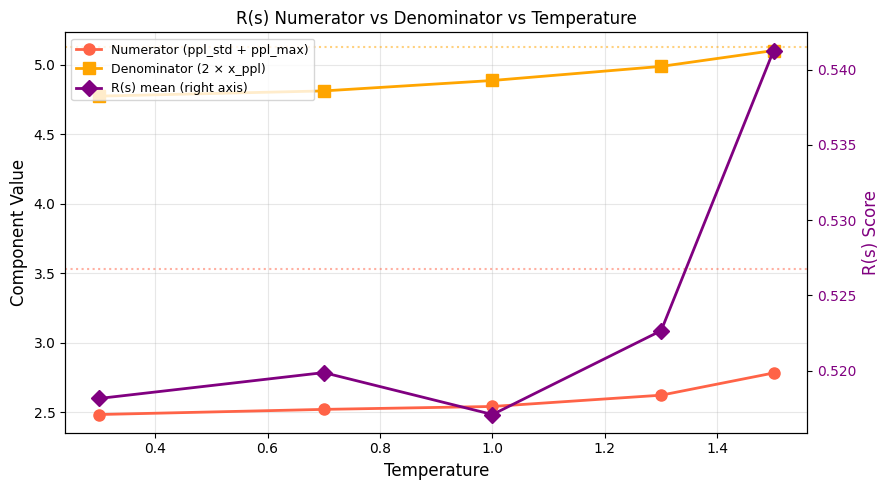

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))

numerators   = [np.nanmean(ai_data[t]["ppl_std"]) + np.nanmean(ai_data[t]["ppl_max"]) for t in TEMPERATURES]
denominators = [2 * np.nanmean(ai_data[t]["x_ppl"]) for t in TEMPERATURES]
rs_means     = [np.nanmean(ai_data[t]["rs"][~np.isnan(ai_data[t]["rs"])]) for t in TEMPERATURES]

ax2 = ax.twinx()
l1, = ax.plot(TEMPERATURES, numerators,   'o-', color='tomato',   lw=2, ms=8, label='Numerator (ppl_std + ppl_max)')
l2, = ax.plot(TEMPERATURES, denominators, 's-', color='orange',   lw=2, ms=8, label='Denominator (2 × x_ppl)')
l3, = ax2.plot(TEMPERATURES, rs_means,    'D-', color='purple',   lw=2, ms=8, label='R(s) mean (right axis)')

h_num = np.nanmean(human_ps) + np.nanmean(human_pm)
h_den = 2 * np.nanmean(human_xp)
ax.axhline(h_num, color='tomato', ls=':', lw=1.5, alpha=0.5, label=f'Human numerator={h_num:.3f}')
ax.axhline(h_den, color='orange', ls=':', lw=1.5, alpha=0.5, label=f'Human denominator={h_den:.3f}')

ax.set_xlabel('Temperature', fontsize=12)
ax.set_ylabel('Component Value', fontsize=12)
ax2.set_ylabel('R(s) Score', fontsize=12, color='purple')
ax2.tick_params(axis='y', labelcolor='purple')
ax.set_title('R(s) Numerator vs Denominator vs Temperature', fontsize=12)
ax.legend(handles=[l1, l2, l3], loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('temp_num_den.png', dpi=150)
plt.show()

In [19]:
summary = {
    "experiment": "Greedy Decoding Assumption Analysis",
    "model_used": "llama-3.3-70b-versatile (Groq)",
    "scorer": "DNA-DetectLLM Falcon-7B / Falcon-7B-Instruct (4-bit NF4)",
    "n_samples": N,
    "temperatures": TEMPERATURES,
    "human_mean": float(np.nanmean(human_rs)),
    "human_std":  float(np.nanstd(human_rs)),
    "ai_by_temperature": {
        str(t): {
            "rs_mean":      float(np.nanmean(ai_data[t]["rs"])),
            "rs_std":       float(np.nanstd(ai_data[t]["rs"])),
            "ppl_std_mean": float(np.nanmean(ai_data[t]["ppl_std"])),
            "ppl_max_mean": float(np.nanmean(ai_data[t]["ppl_max"])),
            "x_ppl_mean":   float(np.nanmean(ai_data[t]["x_ppl"])),
            "auroc":        float(aurocs[i]),
        }
        for i, t in enumerate(TEMPERATURES)
    }
}

with open("temperature_experiment_results.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps({k: v for k, v in summary.items() if k != "ai_by_temperature"}, indent=2))
print()
print(f"{'Temp':<6} {'R(s)':>8} {'AUROC':>8}")
for t in TEMPERATURES:
    d = summary["ai_by_temperature"][str(t)]
    print(f"T={t:<4} {d['rs_mean']:>8.4f} {d['auroc']:>8.4f}")

{
  "experiment": "Greedy Decoding Assumption Analysis",
  "model_used": "llama-3.3-70b-versatile (Groq)",
  "scorer": "DNA-DetectLLM Falcon-7B / Falcon-7B-Instruct (4-bit NF4)",
  "n_samples": 50,
  "temperatures": [
    0.3,
    0.7,
    1.0,
    1.3,
    1.5
  ],
  "human_mean": 0.6881100269516195,
  "human_std": 0.017791553718828467
}

Temp       R(s)    AUROC
T=0.3    0.5181   0.9984
T=0.7    0.5199   0.9956
T=1.0    0.5171   1.0000
T=1.3    0.5227   0.9892
T=1.5    0.5413   0.9660
